In [9]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [10]:
# Cell 2 — Load the dataset and find label column
df = pd.read_csv('cicids2017_cleaned.csv')

# Fix column name spaces
df.columns = df.columns.str.strip()

print(f"✅ Data loaded!")
print(f"📊 Total rows: {df.shape[0]:,}")
print(f"📋 Total columns: {df.shape[1]}")
print(f"\n📝 All column names:")
for col in df.columns:
    print(f"  - {col}")

✅ Data loaded!
📊 Total rows: 2,520,751
📋 Total columns: 53

📝 All column names:
  - Destination Port
  - Flow Duration
  - Total Fwd Packets
  - Total Length of Fwd Packets
  - Fwd Packet Length Max
  - Fwd Packet Length Min
  - Fwd Packet Length Mean
  - Fwd Packet Length Std
  - Bwd Packet Length Max
  - Bwd Packet Length Min
  - Bwd Packet Length Mean
  - Bwd Packet Length Std
  - Flow Bytes/s
  - Flow Packets/s
  - Flow IAT Mean
  - Flow IAT Std
  - Flow IAT Max
  - Flow IAT Min
  - Fwd IAT Total
  - Fwd IAT Mean
  - Fwd IAT Std
  - Fwd IAT Max
  - Fwd IAT Min
  - Bwd IAT Total
  - Bwd IAT Mean
  - Bwd IAT Std
  - Bwd IAT Max
  - Bwd IAT Min
  - Fwd Header Length
  - Bwd Header Length
  - Fwd Packets/s
  - Bwd Packets/s
  - Min Packet Length
  - Max Packet Length
  - Packet Length Mean
  - Packet Length Std
  - Packet Length Variance
  - FIN Flag Count
  - PSH Flag Count
  - ACK Flag Count
  - Average Packet Size
  - Subflow Fwd Bytes
  - Init_Win_bytes_forward
  - Init_Win_bytes_b

In [11]:
# Cell 3 — Explore the data
print("🏷️ Attack types found:")
print(df['Attack Type'].value_counts())
print(f"\n📊 Sample of data:")
df.head()

🏷️ Attack types found:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

📊 Sample of data:


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [12]:
# Cell 4 — Clean and prepare data

# Check for missing values
print("🔍 Missing values per column:")
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")

# Drop missing values if any
df = df.dropna()

# Check for infinite values and remove them
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Separate features (X) and label (y)
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

print(f"\n✅ Data cleaned!")
print(f"📊 Features shape: {X.shape}")
print(f"🏷️ Labels shape: {y.shape}")
print(f"\n🎯 Attack type distribution:")
print(y.value_counts())

🔍 Missing values per column:
Total missing values: 0

✅ Data cleaned!
📊 Features shape: (2520751, 52)
🏷️ Labels shape: (2520751,)

🎯 Attack type distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [13]:
# Cell 5 — Split and Train

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data split done!")
print(f"🎓 Training rows: {X_train.shape[0]:,}")
print(f"🧪 Testing rows: {X_test.shape[0]:,}")

# Train the Random Forest model
print(f"\n⏳ Training model... (this will take 2-5 minutes, please wait)")

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1       # uses all your CPU cores to go faster
)

model.fit(X_train, y_train)

print(f"✅ Model trained successfully!")

# Save the model
joblib.dump(model, 'models/intrusion_detector.pkl')
print(f"💾 Model saved to models/intrusion_detector.pkl")

✅ Data split done!
🎓 Training rows: 2,016,600
🧪 Testing rows: 504,151

⏳ Training model... (this will take 2-5 minutes, please wait)
✅ Model trained successfully!
💾 Model saved to models/intrusion_detector.pkl


In [14]:
# Cell 6 — Evaluate the model
print("🧪 Testing model on unseen data...")
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Overall Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

🧪 Testing model on unseen data...

🎯 Overall Accuracy: 99.84%

📊 Detailed Classification Report:
                precision    recall  f1-score   support

          Bots       0.90      0.76      0.83       384
   Brute Force       1.00      1.00      1.00      1821
          DDoS       1.00      1.00      1.00     25675
           DoS       1.00      1.00      1.00     38912
Normal Traffic       1.00      1.00      1.00    418697
 Port Scanning       0.99      0.99      0.99     18219
   Web Attacks       0.99      0.96      0.98       443

      accuracy                           1.00    504151
     macro avg       0.98      0.96      0.97    504151
  weighted avg       1.00      1.00      1.00    504151



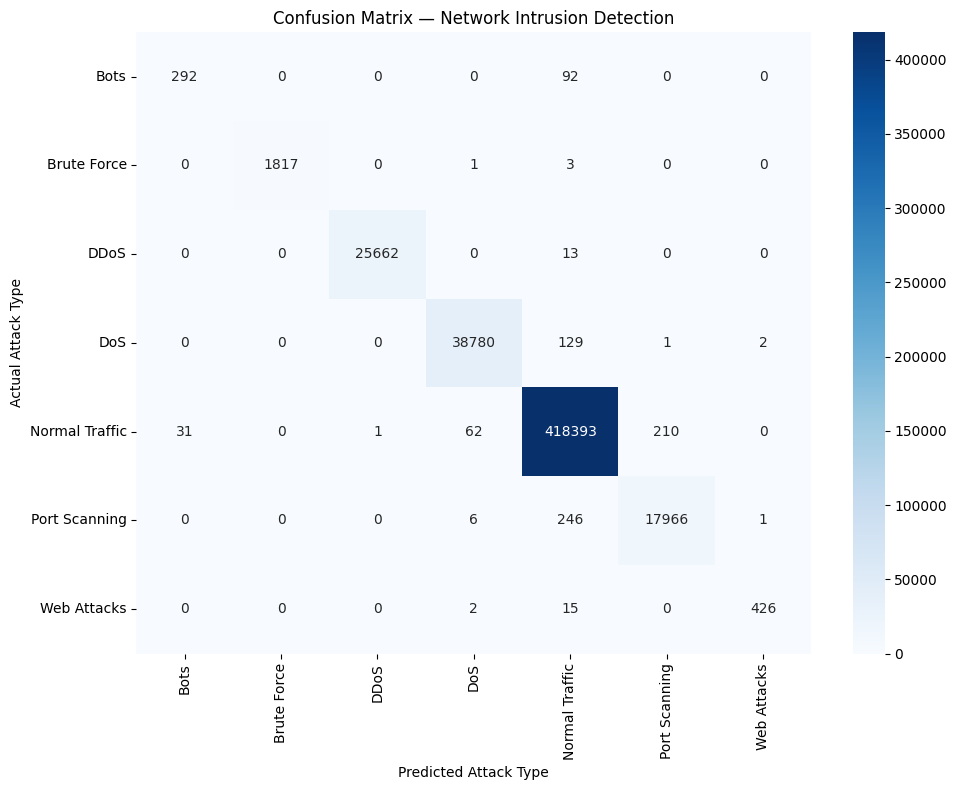

y_test exists: True
y_pred exists: True


In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

os.makedirs('output', exist_ok=True)

plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title('Confusion Matrix — Network Intrusion Detection')
plt.ylabel('Actual Attack Type')
plt.xlabel('Predicted Attack Type')

plt.tight_layout()
plt.savefig('output/confusion_matrix.png')
plt.show()
print('y_test exists:', 'y_test' in globals())
print('y_pred exists:', 'y_pred' in globals())

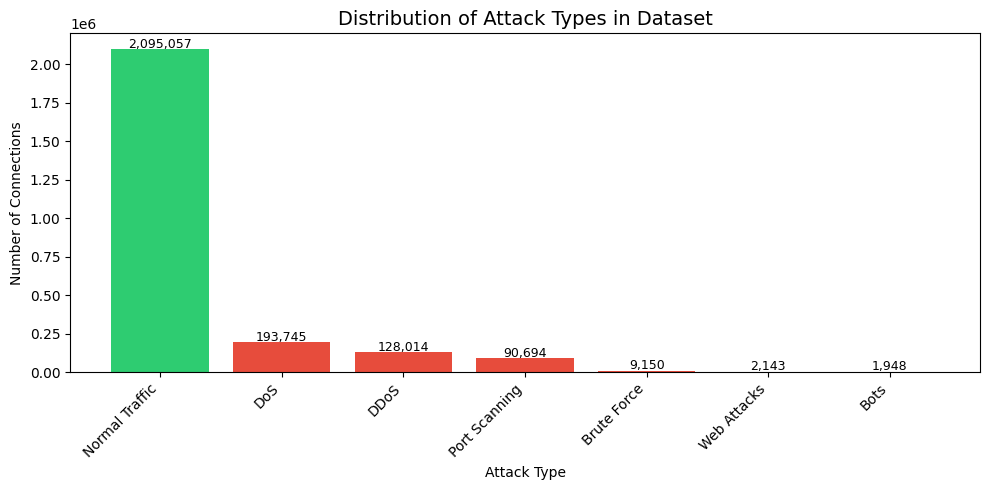

✅ Saved to output/attack_distribution.png


In [16]:
# Cell 8 — Attack Distribution Chart
plt.figure(figsize=(10, 5))
attack_counts = y.value_counts()
colors = ['#2ecc71' if x == 'Normal Traffic' else '#e74c3c' 
          for x in attack_counts.index]
bars = plt.bar(attack_counts.index, attack_counts.values, color=colors)
plt.title('Distribution of Attack Types in Dataset', fontsize=14)
plt.xlabel('Attack Type')
plt.ylabel('Number of Connections')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, attack_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 10000,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/attack_distribution.png', dpi=150)
plt.show()
print("✅ Saved to output/attack_distribution.png")

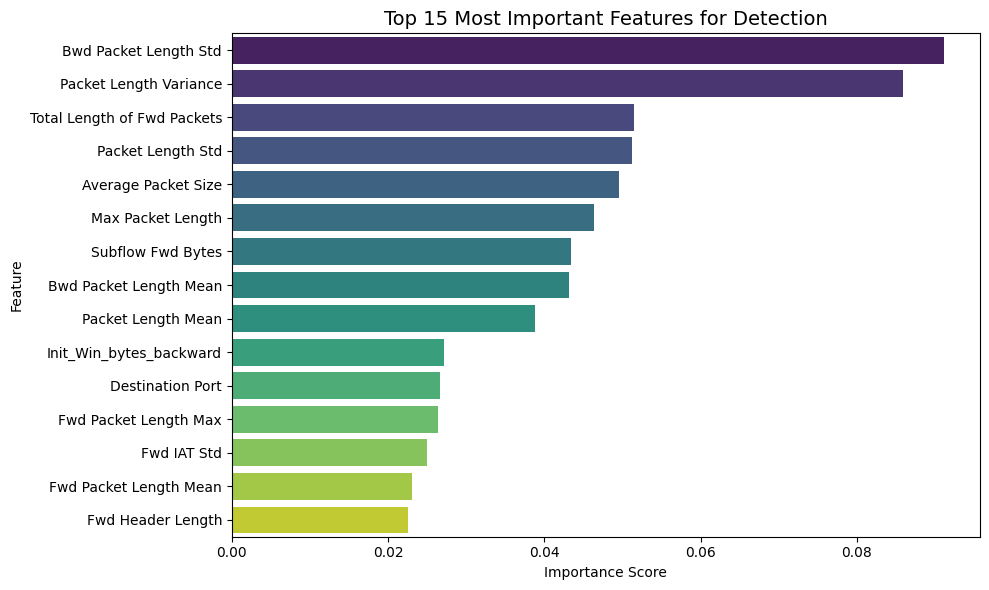

✅ Saved to output/feature_importance.png


In [17]:
# Cell 9 — Top 15 Most Important Features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features for Detection', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150)
plt.show()
print("✅ Saved to output/feature_importance.png")

In [18]:
# Cell 10 — Predict on a single connection (demo)
import random

# Pick a random connection from test set
sample_index = random.randint(0, len(X_test)-1)
sample = X_test.iloc[sample_index:sample_index+1]
actual = y_test.iloc[sample_index]

prediction = model.predict(sample)[0]
confidence = model.predict_proba(sample).max() * 100

print("🔍 LIVE DETECTION DEMO")
print("=" * 40)
print(f"📦 Connection analyzed: #{sample_index}")
print(f"🎯 Predicted: {prediction}")
print(f"✅ Actual:    {actual}")
print(f"💯 Confidence: {confidence:.1f}%")
print("=" * 40)

if prediction == actual:
    print("✅ CORRECT DETECTION!")
else:
    print("❌ Incorrect prediction")

🔍 LIVE DETECTION DEMO
📦 Connection analyzed: #438890
🎯 Predicted: Web Attacks
✅ Actual:    Web Attacks
💯 Confidence: 100.0%
✅ CORRECT DETECTION!
